# AUTOCORRELATION & PARTIAL-AUTOCORRELATION 
#              ARIMA

In [7]:
import pandas as pd
df = pd.read_csv('shampoo.csv',header=0, parse_dates=[0],date_format='%d-%m-%Y')
df.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


<Axes: >

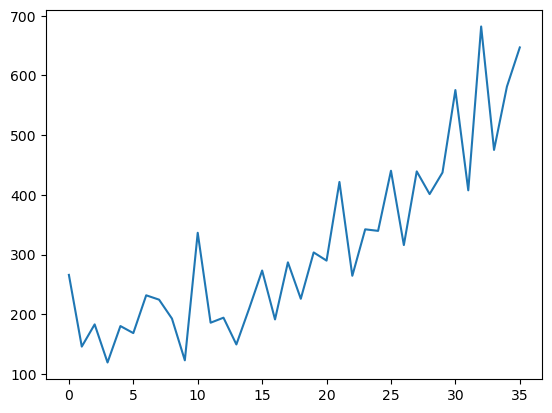

In [9]:
df['Sales'].plot()

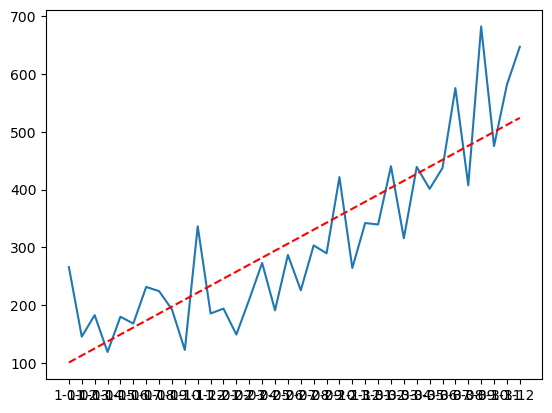

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# replace 'your_date_column' and 'your_value_column' with your actual column names
plt.plot(df['Month'], df['Sales'])

# trend line
z = np.polyfit(range(len(df)), df['Sales'], 1)
plt.plot(np.poly1d(z)(range(len(df))), 'r--')

plt.show()

## AUTOCORRELATION

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

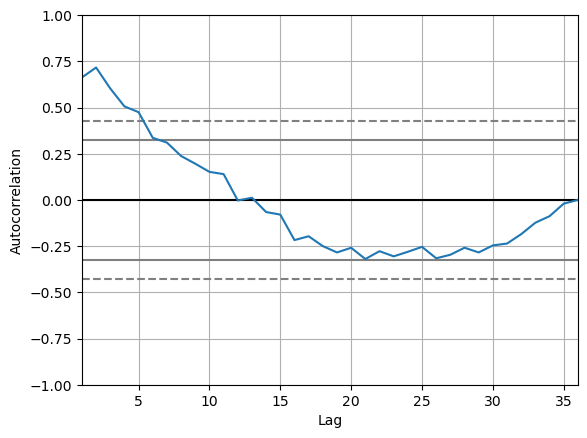

In [19]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['Sales'])

- Take the order of AR(p=) as 5 ( after that it is going inside the CI)

## PARTIAL-AUTOCORRELATION 

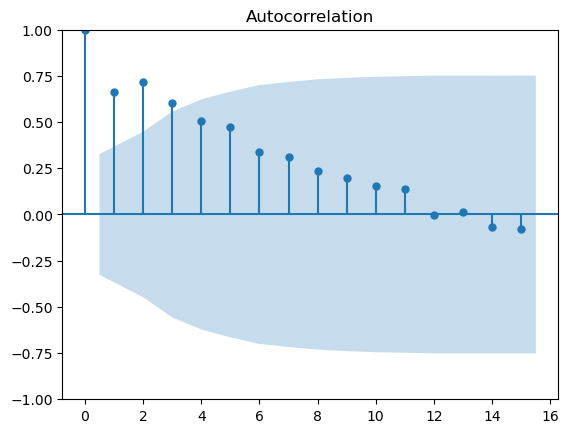

In [27]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Sales'],lags=15);

- We take order of MA(q=) as 2

## ARIMA

In [38]:
from statsmodels.tsa.arima.model import ARIMA

In [41]:
model = ARIMA(df['Sales'], order=(5,2,2))
model_fit = model.fit()
model_fit.summary()

D:\New folder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 2, 2)   Log Likelihood                -191.901
Date:                Sun, 28 Jun 2026   AIC                            399.801
Time:                        14:50:41   BIC                            412.012
Sample:                             0   HQIC                           403.966
                                 - 36                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2741      3.066     -0.416      0.678      -7.283       4.735
ar.L2         -0.9934      3.912     -0.254      0.800      -8.661       6.674
ar.L3         -0.8128      2.923     -0.278      0.781      -6.542       4.917
ar.L4         -0.5075      2.312     -0.220      0.826      -5.038       4.023
ar.L5         -0.0803      1.328     -0.060      0.952      -2.684       2.523
ma.L1         -0.8519      3.156     -0.270      0.787      -7.037       5.333
ma.L2          0.0832      2.548      0.033      0.974      -4.910       5.077
sigma2      3996.2471   1308.563      3.054      0.002    1431.512    6560.982
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 0.42
Prob(Q):                              0.72   Prob(JB):                         0.81
Heteroskedasticity (H):               0.94   Skew:                            -0.00
Prob(H) (two-sided):                  0.92   Kurtosis:                         2.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [45]:
residuals = model_fit.resid
residuals

0     266.000000
1    -251.238807
2     142.505040
3      28.068090
4      83.068409
5      66.236946
6     115.639122
7      87.241913
8      14.836677
9     -99.716257
10    102.089341
11      2.904553
12    -78.371595
13    -70.016026
14    -12.618148
15     46.254012
16     11.567681
17     72.642007
18     37.655436
19     33.284016
20     25.772479
21    137.109774
22    -32.168622
23    -43.864443
24    -19.740565
25     52.788904
26    -70.828930
27     29.552368
28     23.811460
29     -4.506717
30    125.730911
31    -18.377526
32    125.838440
33     -5.257830
34    -66.827182
35     35.952782
dtype: float64

<Axes: >

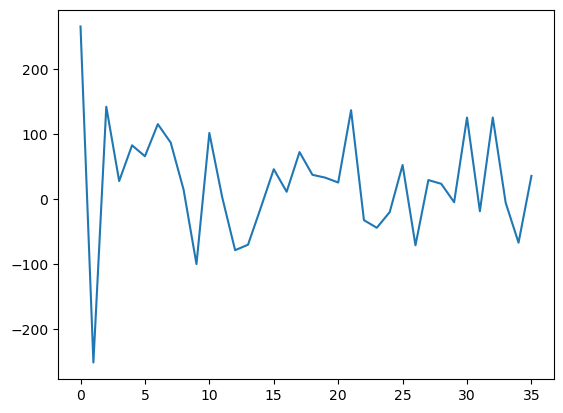

In [46]:
residuals.plot()

In [47]:
residuals.describe()

count     36.000000
mean      24.806048
std       88.931498
min     -251.238807
25%      -18.718286
50%       26.920284
75%       75.248608
max      266.000000
dtype: float64

In [51]:
output = model_fit.forecast()
output

36    608.240313
dtype: float64

In [52]:
model_fit.forecast(5)

36    608.240313
37    700.069324
38    641.957561
39    725.401611
40    727.544084
Name: predicted_mean, dtype: float64

In [55]:
df['Res'] = residuals
df.head

<bound method NDFrame.head of    Month  Sales         Res
0   1-01  266.0  266.000000
1   1-02  145.9 -251.238807
2   1-03  183.1  142.505040
3   1-04  119.3   28.068090
4   1-05  180.3   83.068409
5   1-06  168.5   66.236946
6   1-07  231.8  115.639122
7   1-08  224.5   87.241913
8   1-09  192.8   14.836677
9   1-10  122.9  -99.716257
10  1-11  336.5  102.089341
11  1-12  185.9    2.904553
12  2-01  194.3  -78.371595
13  2-02  149.5  -70.016026
14  2-03  210.1  -12.618148
15  2-04  273.3   46.254012
16  2-05  191.4   11.567681
17  2-06  287.0   72.642007
18  2-07  226.0   37.655436
19  2-08  303.6   33.284016
20  2-09  289.9   25.772479
21  2-10  421.6  137.109774
22  2-11  264.5  -32.168622
23  2-12  342.3  -43.864443
24  3-01  339.7  -19.740565
25  3-02  440.4   52.788904
26  3-03  315.9  -70.828930
27  3-04  439.3   29.552368
28  3-05  401.3   23.811460
29  3-06  437.4   -4.506717
30  3-07  575.5  125.730911
31  3-08  407.6  -18.377526
32  3-09  682.0  125.838440
33  3-10  475.3   

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

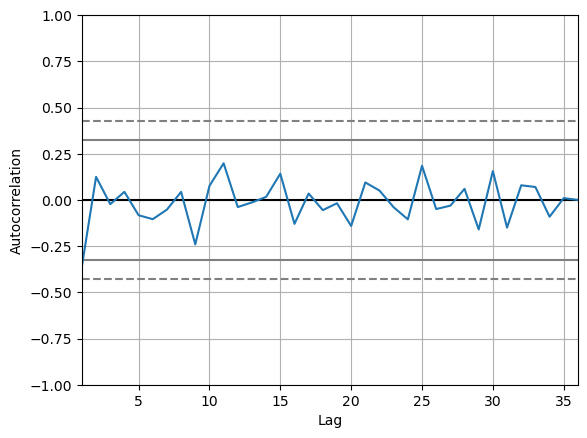

In [56]:
autocorrelation_plot(df['Res'])

- since ACF of Residual lie inside the CI, the noice is white.